In [3]:
import pandas as pd
import warnings

!pip install skforecast
from skforecast.exceptions import IgnoredArgumentWarning

import seaborn as sns
sns.set_theme(palette="colorblind")

warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.3/467.3 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 36.1 MB/s eta 0:00:00


# Ex 6.1

Create three SES models on the Algeria export dataset ([download link](https://otexts.com/fpppy/data/algeria_exports.csv)), with alpha=0.2, 0.5, 0.8. Generate 10-steps ahead, out-of-sample forecasts for each model. Plot the fitted and forecast values. Describe how the fitted curve and the forecast values depend on alpha.

In [5]:
!wget -nc https://otexts.com/fpppy/data/algeria_exports.csv
from skforecast.stats._ets import Ets

df = pd.read_csv("algeria_exports.csv", parse_dates=["ds"], index_col="ds", usecols=["ds", "y"])

# explicitly set the frequency of the index to yearly
df.index.freq = 'YE'

--2026-06-16 16:18:59--  https://otexts.com/fpppy/data/algeria_exports.csv
Resolving otexts.com (otexts.com)... 35.215.112.83
Connecting to otexts.com (otexts.com)|35.215.112.83|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2094 (2.0K) [text/csv]
Saving to: ‘algeria_exports.csv’

algeria_exports.csv 100%[===================>]   2.04K  --.-KB/s    in 0s      

2026-06-16 16:19:00 (520 MB/s) - ‘algeria_exports.csv’ saved [2094/2094]



Comments:

???

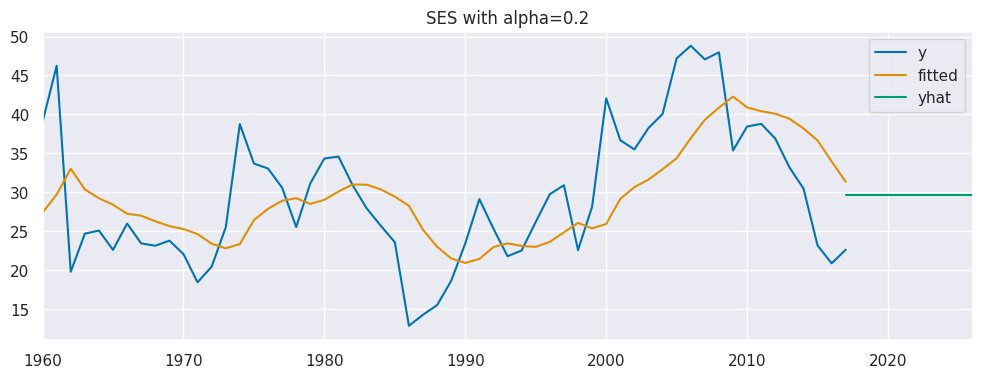

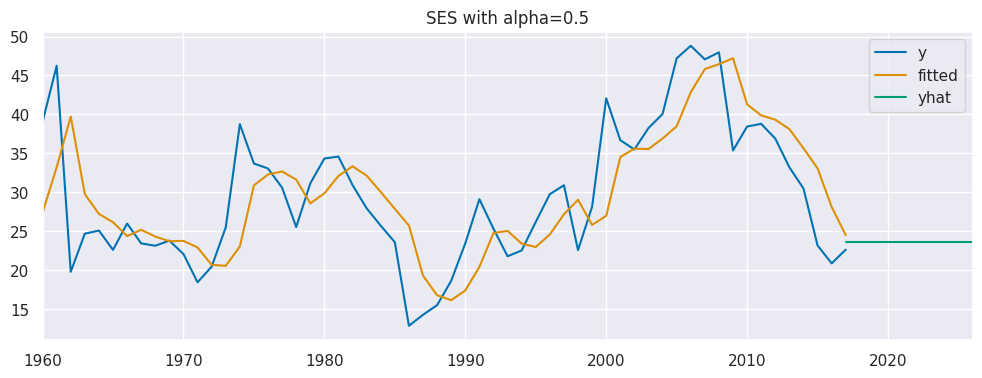

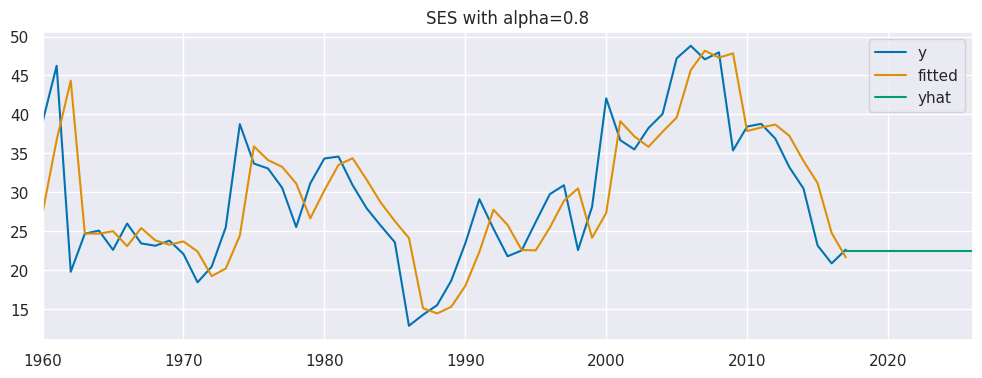

In [9]:
for a in [0.2, 0.5, 0.8]:

    model = Ets(model='ANN', alpha=a)
    model.fit(y=df['y'])

    # values fitted on the full dataset
    fitted = model.fitted_values_

    # predicted values 10 steps at the end of the dataset
    predictions = pd.DataFrame({"yhat": model.predict(steps=10)},
                            index=pd.date_range(start=df.index[-1], periods=10, freq='YE'))

    # plot original series, SES-fitted values and predictions
    tdf = pd.DataFrame({"y": df['y'], "fitted": fitted})
    tdf = tdf.merge(predictions, left_index=True, right_index=True, how='outer')
    tdf.plot(figsize=(12,4), title=f"SES with alpha={a}")

# Ex.6.2

The Australian tourism dataset ([download link](https://otexts.com/fpppy/data/tourism.csv)) contains quarterly numbers of visitor nights during trips made with different purposes. Calculate the values for nation-wide trips, where the purpose was "Holiday" and plot the series. Is there any seasonality? If yes, what is the length of the seasonal cycle?

Construct an Exponential Smoothing model using the AutoETS method on the series, specifying the appropriate length of the seasonal pattern, and describe the best settings found for $\alpha$, $\beta$, $\gamma$ and $\phi$.

Generate forecasts for the next 10 years. Comment on the produced forecasts.

In [10]:
df = pd.read_csv("/content/tourism.csv", parse_dates=["ds"])

In [11]:
df = df[df["Purpose"] == "Holiday"]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6080 entries, 80 to 24159
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   ds       6080 non-null   datetime64[ns]
 1   Region   6080 non-null   object        
 2   State    6080 non-null   object        
 3   Purpose  6080 non-null   object        
 4   y        6080 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 285.0+ KB


In [12]:
# sum the values across different states for the "Holiday" purpose
df = df.groupby("ds")["y"].sum().to_frame()

# explicitly set the frequency of the index to quarterly
df.index.freq = 'QS-OCT'

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 80 entries, 1998-01-01 to 2017-10-01
Freq: QS-OCT
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       80 non-null     float64
dtypes: float64(1)
memory usage: 1.2 KB


<Axes: title={'center': 'Tourism - Holiday purpose'}, xlabel='ds'>

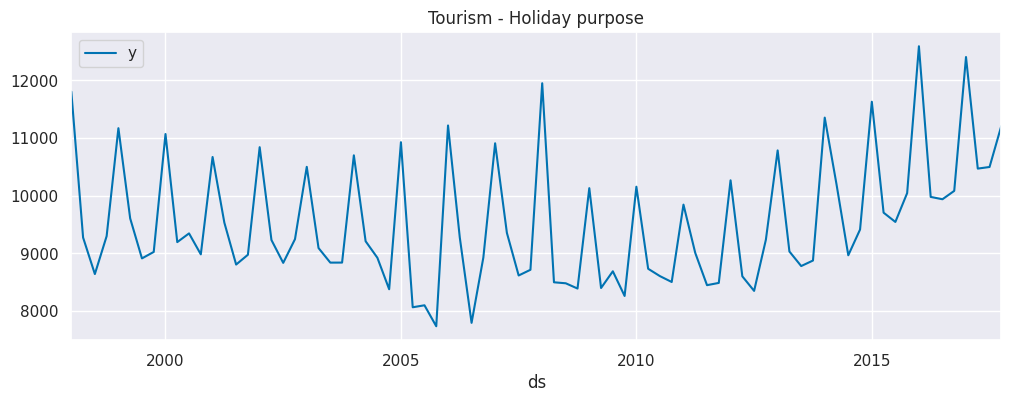

In [13]:
# plot the series
df.plot(figsize=(12,4),title="Tourism - Holiday purpose")

In [14]:
# Run AutoETS with an appropriate value of m for the data
from skforecast.model_selection import grid_search_forecaster
from skforecast.model_selection import backtesting_forecaster

In [15]:
model = Ets(m=4, model=None)
model.fit(y=df['y'])
model.best_params_

{'m': 4,
 'model': 'MAM',
 'damped': False,
 'alpha': np.float64(0.1),
 'beta': np.float64(0.01),
 'gamma': np.float64(0.01),
 'phi': 1.0,
 'lambda_param': None,
 'lambda_auto': False,
 'bias_adjust': True,
 'bounds': 'both',
 'seasonal': True,
 'trend': None,
 'ic': 'aicc',
 'allow_multiplicative': True,
 'allow_multiplicative_trend': False}

Comments:

* alpha=0.1
* beta=0.01
* gamma=0.01
* phi=1.0

In [ ]:
# values fitted on the full dataset
fitted = model.fitted_values_

# predicted values at the end of the dataset
predictions = pd.DataFrame({"yhat": ???},
                           index=pd.date_range(start=df.index[-1], periods=???, freq='QE'))

# plot original series, AutoETS-fitted values and predictions
???

Comments:

???

In [ ]:
# Optional step: re-fitting the model with a dampening trend
model = Ets(m=4, model=None, damped=True)

???

# plot original series, AutoETS-fitted values and predictions
tdf = pd.DataFrame({"y": df['y'], "fitted": fitted})
tdf = tdf.merge(predictions, left_index=True, right_index=True, how='outer')
tdf.plot(figsize=(12,4))

# Ex 6.3

Using the Holiday series from the previous exercise and the best model, run a backtesting of the same model using one-step ahead forecasts, 80% series for model training and compare its quality with a last-value baseline.

Evaluate the models using RMSE and MAE.

Test the significance of the differences between the two models using Diebold-Mariano test. What is the conclusion?

In [ ]:
from skforecast.model_selection import TimeSeriesFold
from skforecast.model_selection import backtesting_forecaster
from sklearn.metrics import root_mean_squared_error

cv = TimeSeriesFold(
         ???
     )

## Last-value baseline

In [ ]:
from skforecast.recursive import ForecasterEquivalentDate

last_value_forecaster = ForecasterEquivalentDate(offset=1, n_offsets=1)

results, predictions_lvbaseline = backtesting_forecaster(
                                        ???
                               )
results

## AutoETS

In [ ]:
from skforecast.stats._ets import Ets
from skforecast.recursive import ForecasterStats
from skforecast.model_selection._validation import backtesting_stats

ets_forecaster = ForecasterStats(estimator=Ets(m=4, model=None))

results, predictions_ets = backtesting_stats(
                                        ???
                               )
results

In [ ]:
# Run Diebold-Mariano test to compare the forecasts of the two models

from dm_test import dm_test

true_values = df.iloc[64:,0]
forecast1 = predictions_lvbaseline['pred']
forecast2 = predictions_ets['pred']

???

# Citing this notebook
If you use this notebook in your work, please cite it as follows:

Pekar, V. (2026). Business Forecasting. Lecture examples and exercises. (Version 1.0.0). URL: https://github.com/vpekar/bf